In [4]:
# Bibliotecas #
from Filtro_LS import *
from Funcoes_auxiliares import *
from Gerador_de_Sinais import main as gerador_sinal_entrada_saida

In [ ]:
# Consantes & Variáveis #

quantidade_de_amostras = 1000

dt = 25 * 10**-9  # tempo entre amostras. Dados proveniente do Shaper
fs = 1 / dt  # frequência de amostragem. 40 MHz
resoluçao = fs / quantidade_de_amostras  # Dados proveniente do Shaper.

In [6]:
# Gerador de sinais #
sinal_original, Readout_Shaper = gerador_sinal_entrada_saida(
    quantidade_de_amostras, seed=42
)

erro_abs_medio = 5.0737
rmse = 6.7204


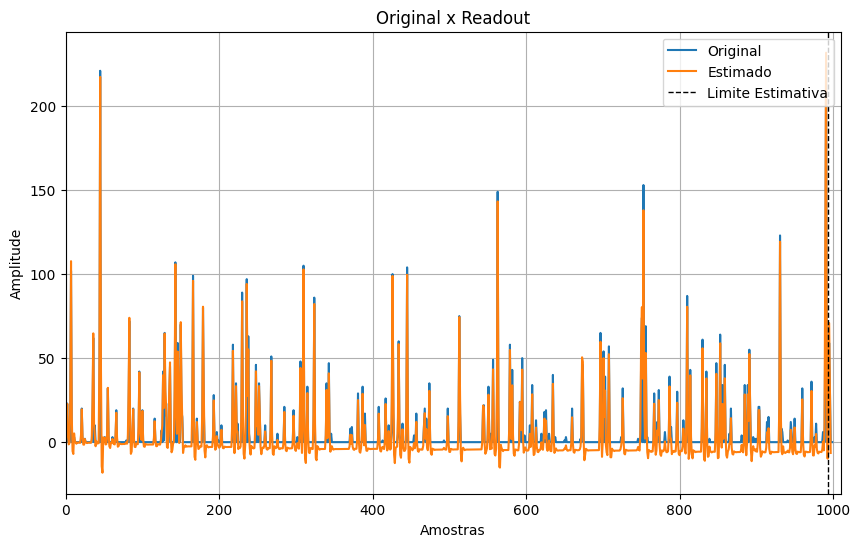

In [23]:
# Plot Original x Readout

r_ro, m_ro = RMSE_e_MAE_por_ordem(
    Readout_Shaper[2:],
    sinal_original[:-2],
    printar=True,
)

plot_estimado_x_original(
    sinal_original,
    Readout_Shaper[2:],
    limite_filtro=quantidade_de_amostras - 7 + 1,
    title="Original x Readout",
)

In [ ]:
# Plot Original x filtro_LS_1

ordem_f_LS1 = 7

s_est_LS1 = filtro_LS(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_f_LS1,
)

lim_filt1 = quantidade_de_amostras + 1 - ordem_f_LS1
# quantidade_de_amostras - ordem_f_LS_ext + 1
r_1, m_1 = RMSE_e_MAE_por_ordem(
    A=s_est_LS1,
    B=sinal_original,
    limite_filtro=lim_filt1,
    printar=True,
)

# plot_estimado_x_original(
#     sinal_original,
#     estimado=s_est_LS1,
#     limite_filtro=quantidade_de_amostras - ordem_f_LS1 + 1,
#     title="Original x filtro_LS_1",
# )

erro_abs_medio = 3.6231
rmse = 4.2044


In [ ]:
# Plot Original x filtro_LS_2
ordem_f_LS2 = 7

s_est_LS2 = filtro_LS_2(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_f_LS2,
)

lim_filt2 = quantidade_de_amostras + 1 - ordem_f_LS2
r_2, m_2 = RMSE_e_MAE_por_ordem(
    A=s_est_LS2,
    B=sinal_original,
    limite_filtro=lim_filt2,
    printar=True,
)


# plot_estimado_x_original(
#     sinal_original,
#     estimado=s_est_LS2,
#     limite_filtro=quantidade_de_amostras - ordem_f_LS2 + 1,
#     title="Original x filtro_LS_2",
# )

erro_abs_medio = 1.2044
rmse = 2.0269


In [22]:
# Plot Original x filtro_LS_com_termos_nao_lineares
ordem_f_LS_ext = 7

s_est_LS_ext = filtro_LS_com_termos_nao_lineares(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_f_LS_ext,
    delay=0,
    # valor_min_clip=np.quantile(Readout_Shaper, 0.25),
)

lim_filt_ext = quantidade_de_amostras + 1 - ordem_f_LS_ext

r_ext, m_ext = RMSE_e_MAE_por_ordem(
    A=s_est_LS_ext,
    B=sinal_original,
    limite_filtro=lim_filt_ext,
    printar=True,
)


# plot_estimado_x_original(
#     sinal_original,
#     estimado=s_est_LS_ext,
#     limite_filtro=quantidade_de_amostras - ordem_f_LS_ext + 1,
#     title="Original x filtro_LS_com_termos_nao_lineares",
# )
"""
Clip min = 0:
erro_abs_medio = 1.0467
rmse = 2.8445

Clip min = q1:
erro_abs_medio = 1.1677
rmse = 2.8349

Q1 e Q4:
erro_abs_medio = 7.4845
rmse = 20.1695

sem limite de filtro:
erro_abs_medio = 1.1677
rmse = 2.8349

com limite:
erro_abs_medio = 0.9263
rmse = 1.5413
"""

erro_abs_medio = 0.9263
rmse = 1.5413


'\nClip min = 0:\nerro_abs_medio = 1.0467\nrmse = 2.8445\n\nClip min = q1:\nerro_abs_medio = 1.1677\nrmse = 2.8349\n\nQ1 e Q4:\nerro_abs_medio = 7.4845\nrmse = 20.1695\n\nsem limite de filtro:\nerro_abs_medio = 1.1677\nrmse = 2.8349\n\ncom limite:\nerro_abs_medio = 0.9263\nrmse = 1.5413\n'

quantidade_de_amostras = 1000
erro_abs_medio = 0.9263
rmse = 1.5413


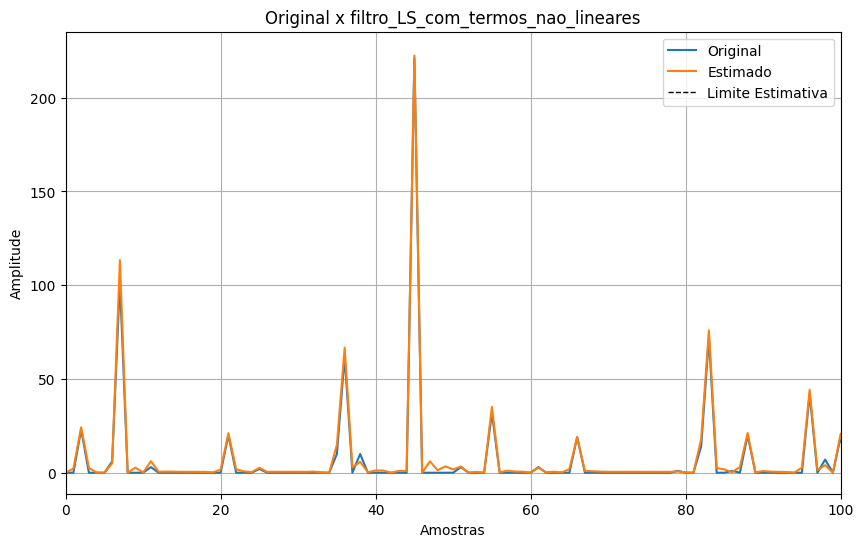

In [31]:
print(f"{quantidade_de_amostras = }")

s_est_LS_ext = filtro_LS_com_termos_nao_lineares(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_f_LS_ext,
    delay=0,
    # valor_min_clip=np.quantile(Readout_Shaper, 0.25),
)

lim_filt_ext = quantidade_de_amostras - ordem_f_LS_ext + 1

r_ext, m_ext = RMSE_e_MAE_por_ordem(
    A=s_est_LS_ext,
    B=sinal_original,
    limite_filtro=lim_filt_ext,
    printar=True,
)

plot_estimado_x_original(
    sinal_original,
    estimado=s_est_LS_ext,
    limite_filtro=quantidade_de_amostras - ordem_f_LS_ext + 1,
    title="Original x filtro_LS_com_termos_nao_lineares",
    xlimite_max=100,
)

In [26]:
def percent(xh, x=sinal_original):
    """
    x = sinal_original
    xh = sinal_estimativa
    """

    rmse = np.sqrt(np.mean((x - xh) ** 2))

    perc_r2 = 100 * (1 - np.sum((x - xh) ** 2) / np.sum((x - np.mean(x)) ** 2))

    rms_x = np.sqrt(np.mean(x**2))
    perc_rmse = 100 * (1 - rmse / rms_x)

    print(f"{rmse = :.5f}, {perc_r2 = :.5f}, {perc_rmse = :.5f}")

In [27]:
percent(Readout_Shaper)
percent(s_est_LS1)
percent(s_est_LS2)
percent(s_est_LS_ext)

rmse = 28.64083, perc_r2 = -110.09076, perc_rmse = -38.70976
rmse = 4.82712, perc_r2 = 94.03222, perc_rmse = 76.62186
rmse = 3.13266, perc_r2 = 97.48659, perc_rmse = 84.82826
rmse = 2.84452, perc_r2 = 97.92769, perc_rmse = 86.22376


In [36]:
def zona_maior_erro(xh, x=sinal_original, limite=quantidade_de_amostras - 7 + 1):
    """
    x: sinal real
    xh: sinal estimado
    """
    erro = x[:limite] - xh[:limite]
    erro_abs = np.abs(erro)

    idx_max = np.argmax(erro_abs)  # posição do maior erro
    maior_erro = erro[idx_max]  # erro com sinal
    maior_erro_abs = erro_abs[idx_max]  # magnitude do erro

    print(f"Maior erro em i={idx_max}")
    print(f"erro = {maior_erro:.6f}")
    print(f"|erro| = {maior_erro_abs:.6f}")
    print(f"x_real = {x[idx_max]:.6f}, x_est = {xh[idx_max]:.6f}")
    return maior_erro_abs

In [37]:
maior_erro_abs = zona_maior_erro(s_est_LS_ext)

Maior erro em i=7
erro = -11.355486
|erro| = 11.355486
x_real = 102.000000, x_est = 113.355486


In [38]:
top = np.argsort(maior_erro_abs)[-10:][::-1]  # 10 maiores
print(top)

[0]


Maior erro em i=7
erro = -11.355486
|erro| = 11.355486
x_real = 102.000000, x_est = 113.355486


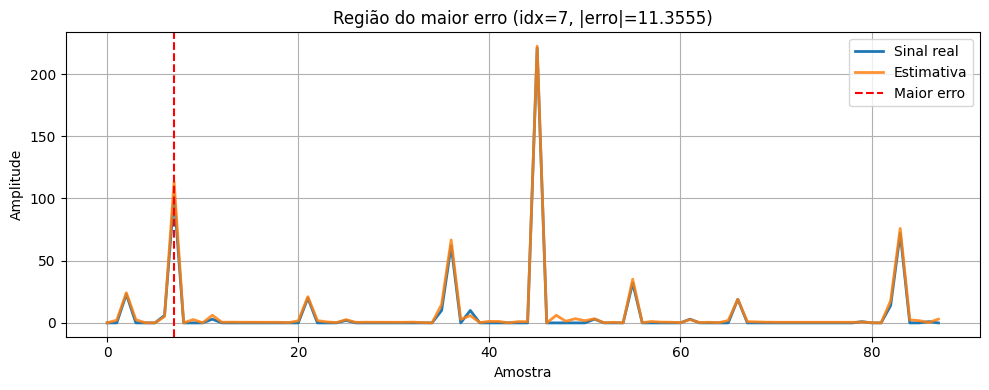

In [ ]:
limite = quantidade_de_amostras - 7 + 1
x = sinal_original[:limite]
xh = s_est_LS_ext[:limite]
# t: vetor de tempo (opcional)
maior_erro_abs = zona_maior_erro(s_est_LS_ext)
erro = x - xh
erro_abs = np.abs(erro)
idx_max = np.argmax(erro_abs)

janela = 80  # pontos para cada lado
ini = max(0, idx_max - janela)
fim = min(len(x), idx_max + janela + 1)

# eixo x do plot
if "t" in locals():
    eixo = t[ini:fim]
    x_label = "Tempo (s)"
    x_pico = t[idx_max]
else:
    eixo = np.arange(ini, fim)
    x_label = "Amostra"
    x_pico = idx_max

plt.figure(figsize=(10, 4))
plt.plot(eixo, x[ini:fim], label="Sinal real", linewidth=2)
plt.plot(eixo, xh[ini:fim], label="Estimativa", linewidth=2, alpha=0.85)
plt.axvline(x=x_pico, color="r", linestyle="--", label="Maior erro")
plt.title(f"Região do maior erro (idx={idx_max}, |erro|={erro_abs[idx_max]:.4f})")
plt.xlabel(x_label)
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()